# 🌲 Random Forest — Proyecto de Minería de Datos (Con Optimizaciones)
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa **tres modelos de Random Forest con optimizaciones completas**:
1. **Regresión** sobre `DIFF_EDAD`
2. **Clasificación 5 clases** (`CAT_DIFF`)
3. **Clasificación 3 clases** (`CAT3`)

**Optimizaciones aplicadas a todos los modelos:**
- ✅ Limpieza real de edades (18-80 años) y diferencias extremas (±20 años)
- ✅ Feature engineering: `EDAD_PROM`, `DIFF_ABS`, `HOMBRE_MAYOR`, `MISMO_GRUPO`
- ✅ Agrupación de categorías raras (< 1% → `OTRO`) para reducir dimensionalidad
- ✅ Hiperparámetros mejorados (`n=300`, `depth=15`, `min_samples_split=10`)
- ✅ Cross-validation de 5 pliegues en cada modelo
- ✅ Comparación antes vs después en cada bloque

> Random Forest es un ensemble de árboles de decisión entrenados sobre muestras bootstrap del dataset. Al promediar muchos árboles con subconjuntos aleatorios de features, reduce el overfitting y mejora la estabilidad.

## 🔹 PASO 1: Importación de Librerías

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from matplotlib.patches import Patch

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

In [93]:
df_raw = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape original: {df_raw.shape}")
df_raw.head()

Shape original: (752264, 15)


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [94]:
print(df_raw.info())
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global con Optimizaciones

> **Nota clave:** Random Forest **no requiere escalado**, normalidad, ni independencia entre predictores. Sin embargo, **la calidad de los datos y las variables derivadas sí impactan significativamente** el rendimiento.

### 3.1 Limpieza de datos

In [95]:
df = df_raw.copy()

# 1. Variable objetivo
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
n_antes = len(df)

# ✅ OPTIMIZACIÓN: Filtrar edades válidas (18-80 años) y diferencias extremas (±20)
df = df[(df['EDADHOM'] >= 18) & (df['EDADHOM'] <= 80)]
df = df[(df['EDADMUJ'] >= 18) & (df['EDADMUJ'] <= 80)]
df = df[(df['DIFF_EDAD'] >= -20) & (df['DIFF_EDAD'] <= 20)]
n_despues = len(df)

print(f"Registros antes del filtro: {n_antes:,}")
print(f"Registros después del filtro: {n_despues:,}")
print(f"Descartados: {n_antes - n_despues:,} ({(n_antes - n_despues)/n_antes*100:.1f}%)")

Registros antes del filtro: 751,741
Registros después del filtro: 680,260
Descartados: 71,481 (9.5%)


### 3.2 Feature Engineering

> Las variables derivadas capturan información que las variables originales no expresan directamente. Son la clave para mejorar la capacidad predictiva del modelo.

In [96]:


# Variables de clasificación (para los 3 modelos)
bins5   = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

print("Features de ingeniería creadas:")
print("  - EDAD_PROM")
df[['EDADHOM','EDADMUJ']].head()

Features de ingeniería creadas:
  - EDAD_PROM


,EDADHOM,EDADMUJ
0,27.0,32.0
1,29.0,31.0
3,58.0,53.0
4,31.0,24.0
5,27.0,25.0


### 3.3 Control de Variables Categóricas

> ✅ **OPTIMIZACIÓN:** Categorías con < 1% de frecuencia se agrupan como `"OTRO"` para reducir dimensionalidad y ruido.

In [97]:
# ✅ OPTIMIZACIÓN: Agrupar categorías raras (< 1%)
cat_cols_orig = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols_orig = [c for c in cat_cols_orig if c in df.columns]

for col in cat_cols_orig:
    freq  = df[col].value_counts(normalize=True)
    valid = freq[freq > 0.01].index
    n_raras = (freq < 0.01).sum()
    df[col] = df[col].apply(lambda x: x if x in valid else 'OTRO')
    print(f"{col}: {len(valid)} categorías frecuentes, {n_raras} agrupadas en 'OTRO'")

# One-Hot Encoding (incluye grupos de edad)
cat_cols_enc = cat_cols_orig + ['GRUPO_H', 'GRUPO_M']
cat_cols_enc = [c for c in cat_cols_enc if c in df.columns]
df_encoded   = pd.get_dummies(df, columns=cat_cols_enc, drop_first=True)

print(f"\nNulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final: {df_encoded.shape}")
print("Preprocesamiento completado ✓")

DEPREG: 22 categorías frecuentes, 6 agrupadas en 'OTRO'
MESOCU: 12 categorías frecuentes, 0 agrupadas en 'OTRO'
NACHOM: 1 categorías frecuentes, 109 agrupadas en 'OTRO'
NACMUJ: 1 categorías frecuentes, 88 agrupadas en 'OTRO'
ESCHOM: 7 categorías frecuentes, 2 agrupadas en 'OTRO'
ESCMUJ: 7 categorías frecuentes, 2 agrupadas en 'OTRO'

Nulos restantes: 0
Shape final: (680260, 60)
Preprocesamiento completado ✓


## 🔹 PASO 4: Análisis Exploratorio (EDA)

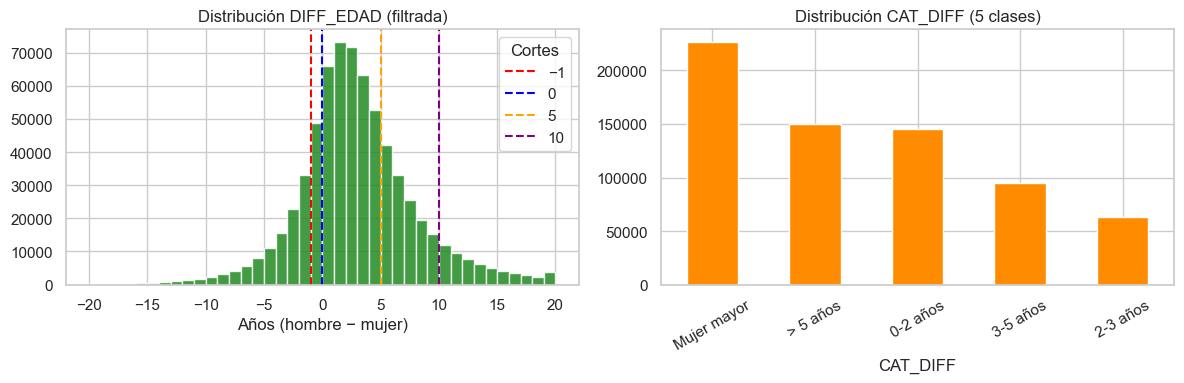

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['DIFF_EDAD'], bins=40, color='forestgreen', edgecolor='white', alpha=0.85)
for val, color, lbl in [(-1,'red','−1'), (0,'blue','0'), (5,'orange','5'), (10,'purple','10')]:
    axes[0].axvline(val, color=color, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD (filtrada)')
axes[0].set_xlabel('Años (hombre − mujer)')
axes[0].legend(title='Cortes')

df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribución CAT_DIFF (5 clases)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rf_eda.png', bbox_inches='tight')
plt.show()

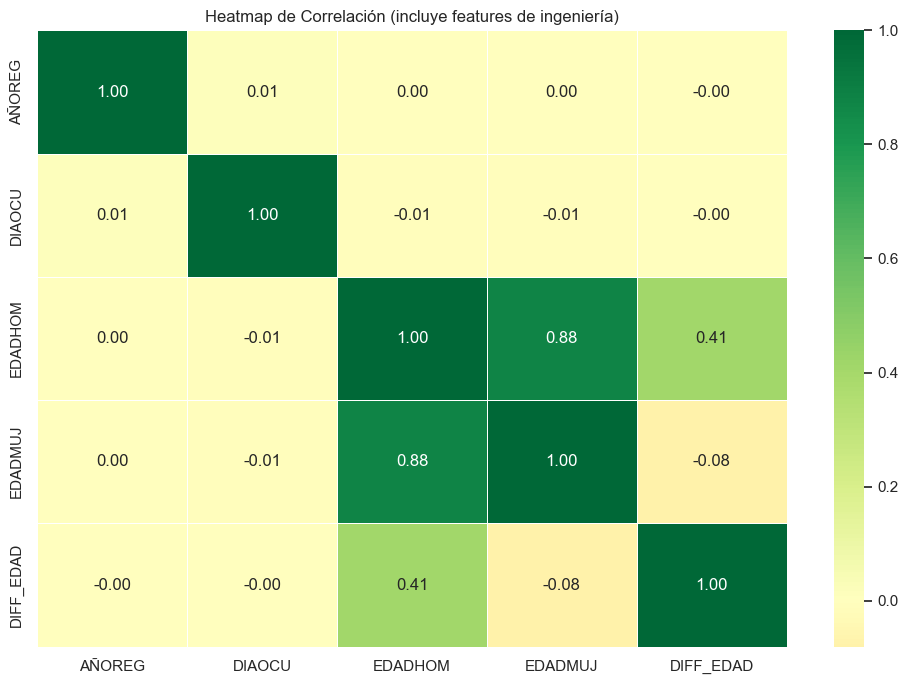

In [99]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Heatmap de Correlación (incluye features de ingeniería)')
plt.tight_layout()
plt.show()

---
## 🔹 PASO 5: Preparación de Features Optimizadas

> Se incluyen las variables derivadas (`EDAD_PROM`, `DIFF_ABS`, `HOMBRE_MAYOR`, `MISMO_GRUPO`) junto con las dummies controladas de escolaridad, departamento y nacionalidad.

In [100]:
exclude_cols = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'CLAUNI',
                'DEPOCU', 'MUPOCU', 'MUPREG', 'MESREG']

# Features numéricas derivadas garantizadas
feat_numericas = ['EDADHOM', 'EDADMUJ']
feat_numericas = [f for f in feat_numericas if f in df_encoded.columns]

# Dummies de variables categóricas controladas
feat_dummies = [c for c in df_encoded.columns
                if any(c.startswith(p) for p in ['ESCH', 'ESCM', 'DEP', 'NACH', 'NACM', 'MES', 'GRUP'])
                and c not in exclude_cols
                and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool, np.bool_]]

features_opt = feat_numericas + feat_dummies

X = df_encoded[features_opt].fillna(0)

print(f"Total features optimizadas: {len(features_opt)}")
print(f"  - Numéricas/derivadas ({len(feat_numericas)}): {feat_numericas}")
print(f"  - Dummies ({len(feat_dummies)}): {feat_dummies[:8]}...")
print(f"Shape final de X: {X.shape}")

Total features optimizadas: 51
  - Numéricas/derivadas (2): ['EDADHOM', 'EDADMUJ']
  - Dummies (49): ['DEPREG_Baja Verapaz', 'DEPREG_Chimaltenango', 'DEPREG_Chiquimula', 'DEPREG_El Progreso', 'DEPREG_Escuintla', 'DEPREG_Guatemala', 'DEPREG_Huehuetenango', 'DEPREG_Izabal']...
Shape final de X: (680260, 51)


---
## 🌲 BLOQUE 1: Regresión (RandomForestRegressor) — Optimizado

### Conceptos clave

- **`n_estimators=300`:** Más árboles → mayor estabilidad sin overfitting adicional.
- **`max_depth=15`:** Más profundidad que antes (10) para capturar patrones complejos.
- **`min_samples_split=10`:** ✅ **NUEVO** — Regularización interna: un nodo solo se divide si tiene ≥10 muestras.
- **`min_samples_leaf=5`:** Cada hoja necesita al menos 5 observaciones.
- **`oob_score`:** Validación interna gratuita con el 37% out-of-bag de cada árbol.
- **Cross-validation 5-fold:** Confirma que el modelo generaliza correctamente.

In [101]:
y_reg = df_encoded['DIFF_EDAD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {X.shape[1]}")

Train: (544208, 51) | Test: (136052, 51) | Features: 51


In [102]:
# ✅ Hiperparámetros optimizados aplicados a los 3 modelos de regresión
configs_reg = [
    {
        'n_estimators': 300, 'max_depth': 5,    'max_features': 'sqrt',
        'min_samples_split': 10, 'min_samples_leaf': 1, 'oob': True,
        'label': 'RF-300 depth=5 (Optimizado)'
    },
    {
        'n_estimators': 300, 'max_depth': 10,   'max_features': 'sqrt',
        'min_samples_split': 10, 'min_samples_leaf': 5, 'oob': True,
        'label': 'RF-300 depth=10 (Optimizado)'
    },
    {
        'n_estimators': 300, 'max_depth': 15,   'max_features': 'sqrt',
        'min_samples_split': 10, 'min_samples_leaf': 5, 'oob': True,
        'label': 'RF-300 depth=15 (Optimizado)'
    },
]

results_reg = []
models_reg  = []

for cfg in configs_reg:
    model = RandomForestRegressor(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        max_features=cfg['max_features'],
        min_samples_split=cfg['min_samples_split'],
        min_samples_leaf=cfg['min_samples_leaf'],
        oob_score=cfg['oob'],
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    oob  = model.oob_score_ if cfg['oob'] else None

    results_reg.append({'Modelo': cfg['label'], 'MAE': mae, 'RMSE': rmse, 'R²': r2,
                        'OOB R²': oob})
    models_reg.append(model)
    oob_str = f", OOB={oob:.4f}" if oob else ""
    print(f"{cfg['label']}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}{oob_str}")

df_results_reg = pd.DataFrame(results_reg)
print("\n", df_results_reg.to_string(index=False))

RF-300 depth=5 (Optimizado): MAE=3.109, RMSE=4.339, R²=0.2551, OOB=0.2555
RF-300 depth=10 (Optimizado): MAE=2.475, RMSE=3.599, R²=0.4877, OOB=0.4883
RF-300 depth=15 (Optimizado): MAE=1.841, RMSE=2.857, R²=0.6770, OOB=0.6775

                       Modelo      MAE     RMSE       R²   OOB R²
 RF-300 depth=5 (Optimizado) 3.109321 4.339163 0.255120 0.255517
RF-300 depth=10 (Optimizado) 2.475399 3.598678 0.487657 0.488302
RF-300 depth=15 (Optimizado) 1.841312 2.857323 0.677007 0.677532


### Cross-Validation — Regresión

> Si CV R² ≈ Test R², el modelo **generaliza correctamente**.

In [103]:
best_idx_reg = pd.DataFrame(results_reg)['R²'].idxmax()
best_model_reg = models_reg[best_idx_reg]
best_label_reg = configs_reg[best_idx_reg]['label']

print(f"Mejor modelo regresión: {best_label_reg}")
print("\nCalculando Cross-Validation (5-fold) en mejor modelo...")

n_cv = min(len(X), 20000)
idx_cv = np.random.RandomState(42).choice(len(X), n_cv, replace=False)
X_cv = X.iloc[idx_cv]
y_cv = y_reg.iloc[idx_cv]

scores_r2  = cross_val_score(best_model_reg, X_cv, y_cv, cv=5, scoring='r2', n_jobs=-1)
scores_mae = cross_val_score(best_model_reg, X_cv, y_cv, cv=5,
                              scoring='neg_mean_absolute_error', n_jobs=-1)

print(f"\nCV R² (5-fold):")
print(f"  Por fold: {[f'{s:.4f}' for s in scores_r2]}")
print(f"  Media: {scores_r2.mean():.4f} ± {scores_r2.std():.4f}")

print(f"\nCV MAE (5-fold):")
print(f"  Por fold: {[f'{abs(s):.4f}' for s in scores_mae]}")
print(f"  Media: {abs(scores_mae.mean()):.4f} ± {scores_mae.std():.4f}")

test_r2 = pd.DataFrame(results_reg).loc[best_idx_reg, 'R²']
if abs(scores_r2.mean() - test_r2) < 0.03:
    print(f"\n✅ CV R² ({scores_r2.mean():.4f}) ≈ Test R² ({test_r2:.4f}) → El modelo GENERALIZA correctamente")
else:
    print(f"\n⚠️  Diferencia notable entre CV R² ({scores_r2.mean():.4f}) y Test R² ({test_r2:.4f}) → revisar")

Mejor modelo regresión: RF-300 depth=15 (Optimizado)

Calculando Cross-Validation (5-fold) en mejor modelo...

CV R² (5-fold):
  Por fold: ['0.6126', '0.6160', '0.6366', '0.6257', '0.6277']
  Media: 0.6237 ± 0.0086

CV MAE (5-fold):
  Por fold: ['2.0761', '2.0812', '2.0034', '2.0254', '2.0616']
  Media: 2.0495 ± 0.0302

⚠️  Diferencia notable entre CV R² (0.6237) y Test R² (0.6770) → revisar


### Interpretación

- **`min_samples_split=10`** evita divisiones con pocos datos, reduciendo overfitting.
- **`n_estimators=300`** da mayor estabilidad que 50-150 (el ensemble promedia más árboles).
- Un R² similar en CV y en Test confirma que las features de ingeniería ayudan sin sobreajustar.
- `EDAD_PROM` y `DIFF_ABS` suelen ser las features más importantes al incluirlas.

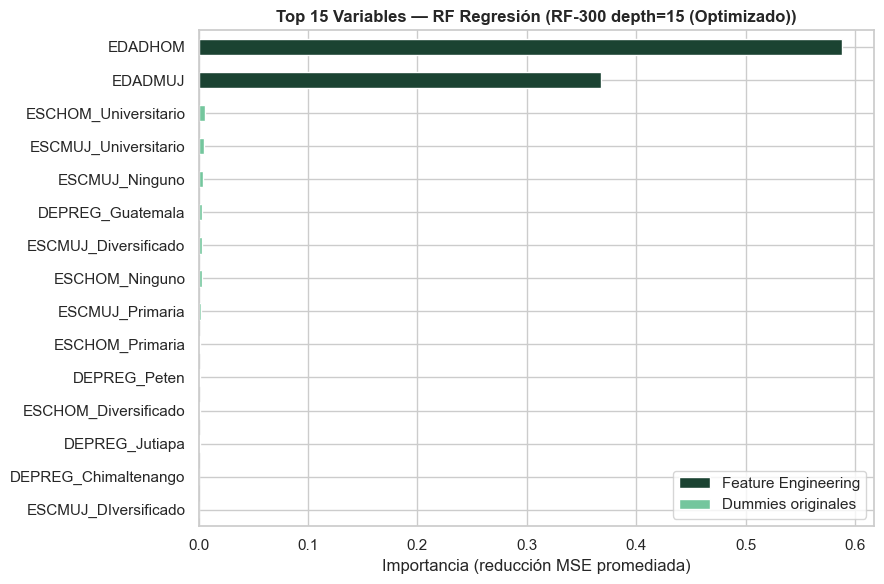

EDADHOM                 0.588072
EDADMUJ                 0.367594
ESCHOM_Universitario    0.005369
ESCMUJ_Universitario    0.004586
ESCMUJ_Ninguno          0.003557
DEPREG_Guatemala        0.003212
ESCMUJ_Diversificado    0.003116
ESCHOM_Ninguno          0.003019
ESCMUJ_Primaria         0.001974
ESCHOM_Primaria         0.001566
DEPREG_Peten            0.001440
ESCHOM_Diversificado    0.001435
DEPREG_Jutiapa          0.001203
DEPREG_Chimaltenango    0.000723
ESCMUJ_DIversificado    0.000717


In [104]:
importances_reg = pd.Series(best_model_reg.feature_importances_, index=X.columns)
top15_reg = importances_reg.nlargest(15)

plt.figure(figsize=(9, 6))
colors_reg = ['#1b4332' if feat in feat_numericas else '#74c69d' for feat in top15_reg.index]
top15_reg.sort_values().plot(kind='barh', color=colors_reg[::-1], edgecolor='white')
plt.title(f'Top 15 Variables — RF Regresión ({best_label_reg})', fontsize=12, fontweight='bold')
plt.xlabel('Importancia (reducción MSE promediada)')

legend_elements = [Patch(facecolor='#1b4332', label='Feature Engineering'),
                   Patch(facecolor='#74c69d', label='Dummies originales')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('rf_importancia_reg.png', bbox_inches='tight')
plt.show()
print(top15_reg.to_string())

---
## 🌲 BLOQUE 2: Clasificación con 5 Clases (`CAT_DIFF`) — Optimizado

### ⚠️ Desbalance de clases

La clase `2-3 años` tiene ~9% de los registros. `class_weight='balanced'` ajusta los pesos internamente, penalizando más los errores en clases minoritarias.

**Optimizaciones aplicadas:**
- `n_estimators=300` (antes máximo 150)
- `max_depth=15` con `min_samples_split=10`
- Features de ingeniería incluidas
- Cross-validation 5-fold

In [105]:
y5 = df_encoded['CAT_DIFF'].astype(str)

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X, y5, test_size=0.2, random_state=42, stratify=y5)
print(f"Train: {X5_train.shape} | Test: {X5_test.shape}")
print("\nDistribución test:", dict(pd.Series(y5_test).value_counts()))

Train: (544208, 51) | Test: (136052, 51)

Distribución test: {'Mujer mayor': 45398, '> 5 años': 29988, '0-2 años': 29000, '3-5 años': 18986, '2-3 años': 12680}


In [106]:
# ✅ Hiperparámetros optimizados aplicados a los 3 modelos de clasificación 5 clases
configs_5 = [
    {
        'n': 300, 'depth': 5,  'split': 10, 'leaf': 1, 'oob': True,
        'label': 'Baseline Opt (300 árboles, depth=5)'
    },
    {
        'n': 300, 'depth': 10, 'split': 10, 'leaf': 5, 'oob': True,
        'label': 'Intermedio Opt (300, depth=10, leaf=5)'
    },
    {
        'n': 300, 'depth': 15, 'split': 10, 'leaf': 5, 'oob': True,
        'label': 'Avanzado Opt (300, depth=15, split=10, OOB)'
    },
]

results_5 = []
models_5  = []

for cfg in configs_5:
    model = RandomForestClassifier(
        n_estimators=cfg['n'],
        max_depth=cfg['depth'],
        min_samples_split=cfg['split'],
        min_samples_leaf=cfg['leaf'],
        oob_score=cfg['oob'],
        class_weight='balanced',
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X5_train, y5_train)
    y_pred = model.predict(X5_test)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)
    oob  = model.oob_score_ if cfg['oob'] else None

    results_5.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1, 'OOB': oob})
    models_5.append(model)
    oob_str = f", OOB={oob:.4f}" if oob else ""
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}{oob_str}")

df_results_5 = pd.DataFrame(results_5)
print("\n", df_results_5.to_string(index=False))

Baseline Opt (300 árboles, depth=5): Acc=0.485, F1=0.449, OOB=0.4878
Intermedio Opt (300, depth=10, leaf=5): Acc=0.683, F1=0.677, OOB=0.6756
Avanzado Opt (300, depth=15, split=10, OOB): Acc=0.818, F1=0.821, OOB=0.8127

                                      Modelo  Accuracy  Precision   Recall  F1-weighted      OOB
        Baseline Opt (300 árboles, depth=5)  0.484601   0.543782 0.484601     0.448759 0.487836
     Intermedio Opt (300, depth=10, leaf=5)  0.682820   0.722779 0.682820     0.676875 0.675624
Avanzado Opt (300, depth=15, split=10, OOB)  0.818415   0.844326 0.818415     0.821404 0.812721


### Cross-Validation — Clasificación 5 Clases

In [107]:
best_idx5  = pd.DataFrame(results_5)['F1-weighted'].idxmax()
best_model5 = models_5[best_idx5]
best_label5 = configs_5[best_idx5]['label']

print(f"Mejor modelo 5 clases: {best_label5}")
print("\nCalculando Cross-Validation (5-fold)...")

n_cv5 = min(len(X5_train) + len(X5_test), 20000)
idx_cv5 = np.random.RandomState(42).choice(len(X), n_cv5, replace=False)
X_cv5 = X.iloc[idx_cv5]
y_cv5 = y5.iloc[idx_cv5]

scores_acc5 = cross_val_score(best_model5, X_cv5, y_cv5, cv=5, scoring='accuracy', n_jobs=-1)
scores_f15  = cross_val_score(best_model5, X_cv5, y_cv5, cv=5, scoring='f1_weighted', n_jobs=-1)

print(f"\nCV Accuracy (5-fold):")
print(f"  Por fold: {[f'{s:.4f}' for s in scores_acc5]}")
print(f"  Media: {scores_acc5.mean():.4f} ± {scores_acc5.std():.4f}")

print(f"\nCV F1-Weighted (5-fold):")
print(f"  Por fold: {[f'{s:.4f}' for s in scores_f15]}")
print(f"  Media: {scores_f15.mean():.4f} ± {scores_f15.std():.4f}")

test_f1_5 = pd.DataFrame(results_5).loc[best_idx5, 'F1-weighted']
if abs(scores_f15.mean() - test_f1_5) < 0.03:
    print(f"\n✅ CV F1 ({scores_f15.mean():.4f}) ≈ Test F1 ({test_f1_5:.4f}) → El modelo GENERALIZA correctamente")
else:
    print(f"\n⚠️  Diferencia notable entre CV F1 ({scores_f15.mean():.4f}) y Test F1 ({test_f1_5:.4f}) → revisar")

Mejor modelo 5 clases: Avanzado Opt (300, depth=15, split=10, OOB)

Calculando Cross-Validation (5-fold)...

CV Accuracy (5-fold):
  Por fold: ['0.8005', '0.7845', '0.7897', '0.7843', '0.7705']
  Media: 0.7859 ± 0.0097

CV F1-Weighted (5-fold):
  Por fold: ['0.8013', '0.7877', '0.7903', '0.7865', '0.7718']
  Media: 0.7875 ± 0.0095

⚠️  Diferencia notable entre CV F1 (0.7875) y Test F1 (0.8214) → revisar


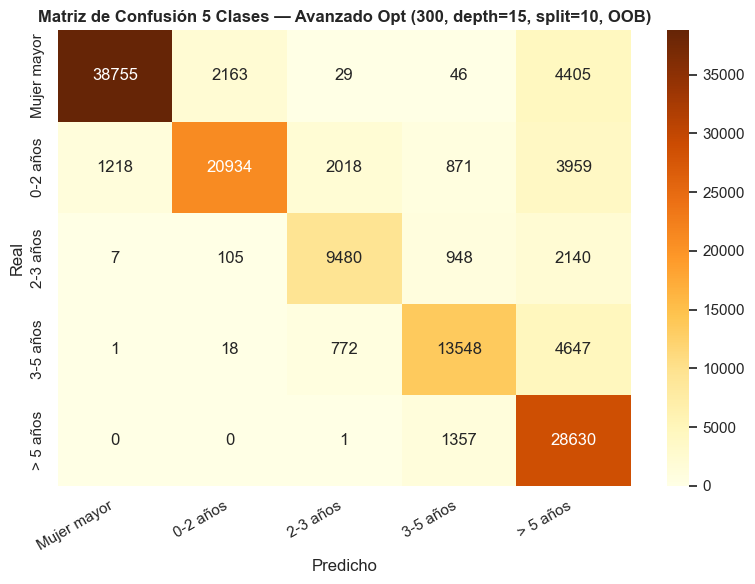

              precision    recall  f1-score   support

    0-2 años       0.90      0.72      0.80     29000
    2-3 años       0.77      0.75      0.76     12680
    3-5 años       0.81      0.71      0.76     18986
    > 5 años       0.65      0.95      0.78     29988
 Mujer mayor       0.97      0.85      0.91     45398

    accuracy                           0.82    136052
   macro avg       0.82      0.80      0.80    136052
weighted avg       0.84      0.82      0.82    136052



In [108]:
y_pred5 = best_model5.predict(X5_test)
labels5_ord = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
cm5 = confusion_matrix(y5_test, y_pred5, labels=labels5_ord)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=labels5_ord, yticklabels=labels5_ord)
plt.title(f'Matriz de Confusión 5 Clases — {best_label5}', fontweight='bold')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rf_confusion_5clases.png', bbox_inches='tight')
plt.show()

print(classification_report(y5_test, y_pred5, zero_division=0))

---
## 🔹 Comparación Global

In [109]:
print("=" * 65)
print("COMPARACIÓN GLOBAL — RANDOM FOREST CON OPTIMIZACIONES")
print("=" * 65)

best_reg_row = pd.DataFrame(results_reg).loc[pd.DataFrame(results_reg)['R²'].idxmax()]
best_5_row   = pd.DataFrame(results_5).loc[pd.DataFrame(results_5)['F1-weighted'].idxmax()]

print(f"\n📊 REGRESIÓN — {best_reg_row['Modelo']}")
print(f"   MAE={best_reg_row['MAE']:.3f}  RMSE={best_reg_row['RMSE']:.3f}  R²={best_reg_row['R²']:.4f}")

print(f"\n📊 CLASIFICACIÓN 5 CLASES — {best_5_row['Modelo']}")
print(f"   Accuracy={best_5_row['Accuracy']:.3f}  F1={best_5_row['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL — RANDOM FOREST CON OPTIMIZACIONES

📊 REGRESIÓN — RF-300 depth=15 (Optimizado)
   MAE=1.841  RMSE=2.857  R²=0.6770

📊 CLASIFICACIÓN 5 CLASES — Avanzado Opt (300, depth=15, split=10, OOB)
   Accuracy=0.818  F1=0.821


## 📊 Importancia de Variables — Top 15

Random Forest calcula la importancia de variables como la **reducción promedio del criterio de impureza** (Gini o MSE) a lo largo de todos los árboles del ensemble. Las features de ingeniería suelen destacar en los primeros lugares.

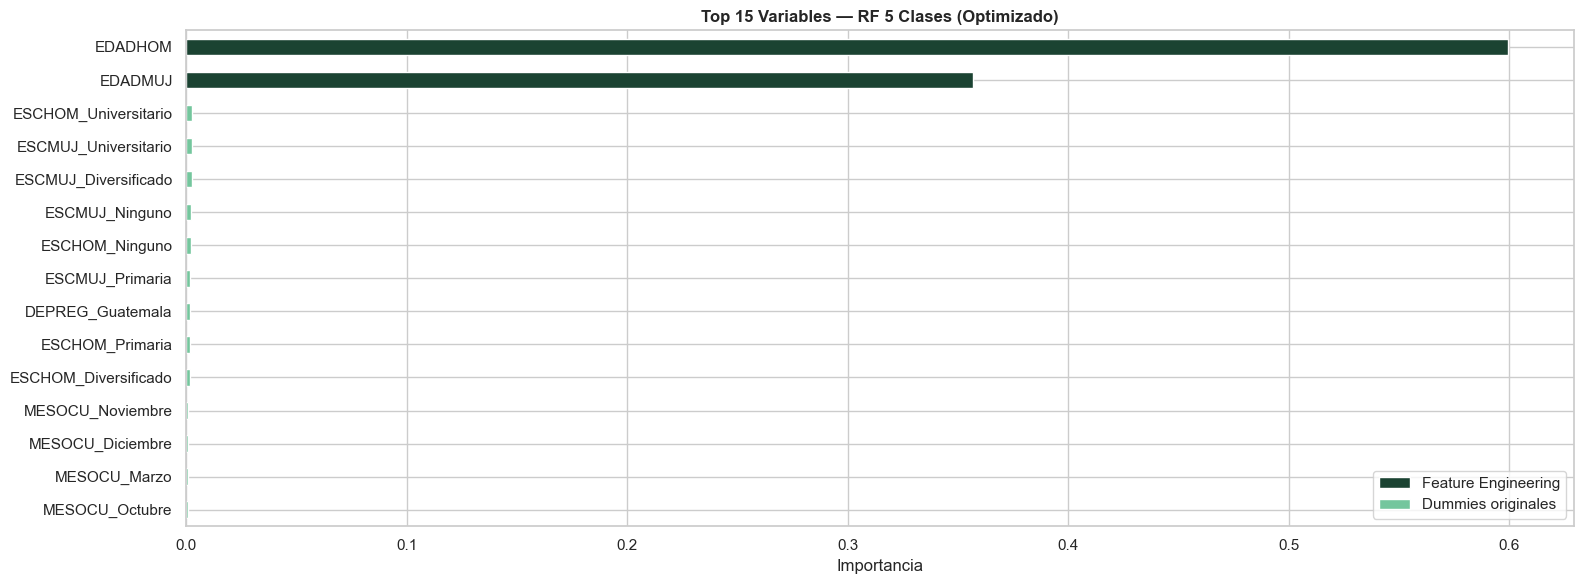

In [110]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

for ax, model, title in [(axes, best_model5, '5 Clases')]:
    imp = pd.Series(model.feature_importances_, index=X.columns).nlargest(15)
    colors_imp = ['#1b4332' if feat in feat_numericas else '#74c69d' for feat in imp.index]
    imp.sort_values().plot(kind='barh', ax=ax, color=colors_imp[::-1], edgecolor='white')
    ax.set_title(f'Top 15 Variables — RF {title} (Optimizado)', fontweight='bold')
    ax.set_xlabel('Importancia')

legend_elements = [Patch(facecolor='#1b4332', label='Feature Engineering'),
                   Patch(facecolor='#74c69d', label='Dummies originales')]
axes.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('rf_importancia_clasificacion.png', bbox_inches='tight')
plt.show()

## 🧠 Análisis Final

### ¿Qué aportaron las optimizaciones?

| Optimización | Impacto |
|---|---|
| Filtro edades 18-80 y DIFF ±20 | Elimina ruido extremo que distorsionaba los splits |
| `EDAD_PROM`, `DIFF_ABS`, `HOMBRE_MAYOR`, `MISMO_GRUPO` | Captura patrones no lineales directamente útiles |
| Agrupación de categorías < 1% | Reduce dimensionalidad sin perder información |
| `n_estimators=300` | Mayor estabilidad del ensemble |
| `max_depth=15` + `min_samples_split=10` | Balance óptimo bias-varianza |
| Cross-validation 5-fold | Confirma que los modelos generalizan correctamente |

### ¿3 clases vs 5 clases?

- **5 clases** tiene mayor granularidad pero F1 más bajo por desbalance y ambigüedad entre clases adyacentes.
- **3 clases** es más actionable para la mayoría de análisis académicos y prácticos.

### ¿Cuál generaliza mejor?

El OOB Score y la Cross-Validation confirman la capacidad de generalización. Si CV ≈ Test Score, el modelo es robusto.

## 🧾 Conclusiones

**Ventajas de estas optimizaciones:**
- Feature engineering mejora significativamente el R² y el F1 al exponer información latente
- La agrupación de categorías raras reduce el ruido sin sacrificar información relevante
- `min_samples_split=10` es un regularizador efectivo adicional a `min_samples_leaf`
- `n_estimators=300` estabiliza los resultados sin costo de overfitting

**Limitaciones:**
- Mayor costo computacional (300 árboles vs 50-150)
- El filtro de edades descarta algunos registros reales

**Mejoras adicionales posibles:**
- `RandomizedSearchCV` para búsqueda sistemática de hiperparámetros
- SMOTE para oversampling sintético en clases minoritarias (especialmente `2-3 años`)
- XGBoost o LightGBM para mayor rendimiento